# Classical MLP Classifier

Binary classification on the Iris dataset using a Multi-Layer Perceptron (MLP),
a classical dense neural network.

This notebook is the classical baseline for the `neural_network` experiment.  
Results are saved to `mlp_results.json` for use in `comparison/comparison.ipynb`.

**Configuration variable:** `N_FEATURES` controls how many features are used (2 or 4).  
For the 4-feature version, results are saved to `mlp_results_4f.json` automatically.

## Imports

In [2]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Configuration

In [3]:
N_FEATURES  = 2          # 2 or 4
TEST_SIZE   = 0.2        # fraction of data held out for testing
RANDOM_SEED = 42         # reproducibility
MAX_ITER    = 500        # maximum training iterations

# Architecture: two hidden layers.
# Kept intentionally small to match the parameter count of the QNN.
# With N_FEATURES=2: (2->4->4->1) = 8+4+4+1 = ~30 parameters
# With N_FEATURES=4: (4->8->4->1) = 32+8+4+1 = ~60 parameters
HIDDEN_LAYERS = (4, 4) if N_FEATURES == 2 else (8, 4)

RESULTS_FILE = "mlp_results.json" if N_FEATURES == 2 else "mlp_results_4f.json"

print(f"Configuration  : N_FEATURES={N_FEATURES}, MAX_ITER={MAX_ITER}")
print(f"Hidden layers  : {HIDDEN_LAYERS}")
print(f"Results file   : {RESULTS_FILE}")

Configuration  : N_FEATURES=2, MAX_ITER=500
Hidden layers  : (4, 4)
Results file   : mlp_results.json


## Dataset

Identical preprocessing to the other experiments: Iris restricted to classes 1 and 2
(Versicolor vs Virginica), scaled to [0, 1], same train/test split and random seed.

In [4]:
iris = load_iris()

mask   = iris.target != 0
X_full = iris.data[mask]
y_full = iris.target[mask] - 1

if N_FEATURES == 2:
    X = X_full[:, 2:4]
    feature_names = ["petal length", "petal width"]
else:
    X = X_full
    feature_names = list(iris.feature_names)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

print(f"Total samples : {len(X_scaled)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features      : {feature_names}")
print(f"Class balance (train): {np.bincount(y_train)}")

Total samples : 100
Train samples : 80
Test samples  : 20
Features      : ['petal length', 'petal width']
Class balance (train): [40 40]


## Classical Algorithm — MLP

A Multi-Layer Perceptron is a fully connected feedforward neural network.
Each neuron computes a weighted sum of its inputs and applies a non-linear activation
function (ReLU here). Training uses backpropagation: gradients of the loss are computed
analytically and the weights are updated with the Adam optimizer.

**Architecture choice:** the hidden layers are kept deliberately small so that the total
number of trainable parameters is comparable to the QNN ansatz. This makes the comparison
fairer in terms of model capacity.

In [5]:
def build_mlp():
    return MLPClassifier(
        hidden_layer_sizes = HIDDEN_LAYERS,
        activation         = "relu",
        solver             = "adam",
        max_iter           = MAX_ITER,
        random_state       = RANDOM_SEED,
        early_stopping     = False,
    )


def count_mlp_parameters(model):
    """Count total trainable parameters (weights + biases) after fitting."""
    total = 0
    for coef in model.coefs_:
        total += coef.size
    for intercept in model.intercepts_:
        total += intercept.size
    return total


mlp = build_mlp()

t0         = time.perf_counter()
mlp.fit(X_train, y_train)
train_time = time.perf_counter() - t0

n_params = count_mlp_parameters(mlp)

print(f"Training time      : {train_time:.4f} s")
print(f"Iterations run     : {mlp.n_iter_}")
print(f"Trainable parameters: {n_params}")

Training time      : 0.1784 s
Iterations run     : 500
Trainable parameters: 37


/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## Evaluation

In [6]:
y_pred_train = mlp.predict(X_train)
y_pred_test  = mlp.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)

cv_scores = cross_val_score(mlp, X_scaled, y_full, cv=5, scoring="accuracy")

print(f"Train accuracy : {acc_train:.4f}")
print(f"Test accuracy  : {acc_test:.4f}")
print(f"CV accuracy    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print(classification_report(y_test, y_pred_test,
                             target_names=["Versicolor", "Virginica"]))

/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged ye

Train accuracy : 0.9750
Test accuracy  : 0.8000
CV accuracy    : 0.9500 ± 0.0447

              precision    recall  f1-score   support

  Versicolor       0.75      0.90      0.82        10
   Virginica       0.88      0.70      0.78        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20



/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## Plots

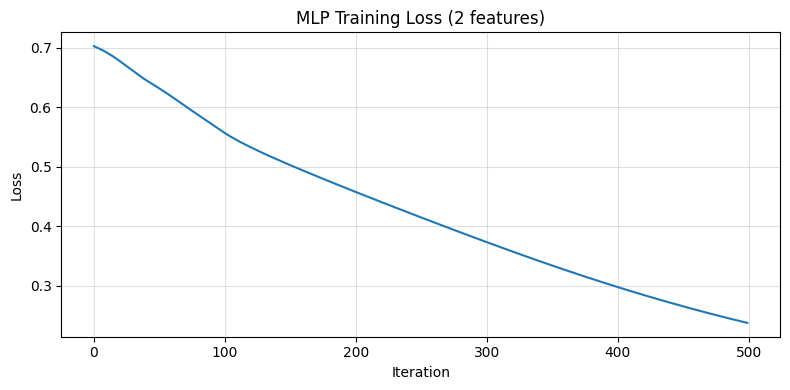

In [7]:
# --- Loss curve ---
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color="tab:blue")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title(f"MLP Training Loss ({N_FEATURES} features)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"mlp_loss_curve{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

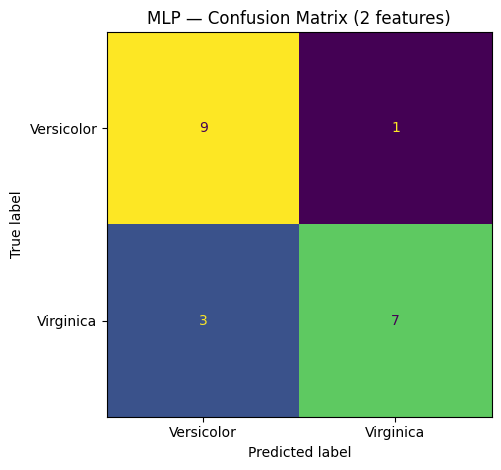

In [8]:
# --- Confusion matrix ---
cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"MLP — Confusion Matrix ({N_FEATURES} features)")
plt.tight_layout()
plt.savefig(f"mlp_confusion_matrix{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

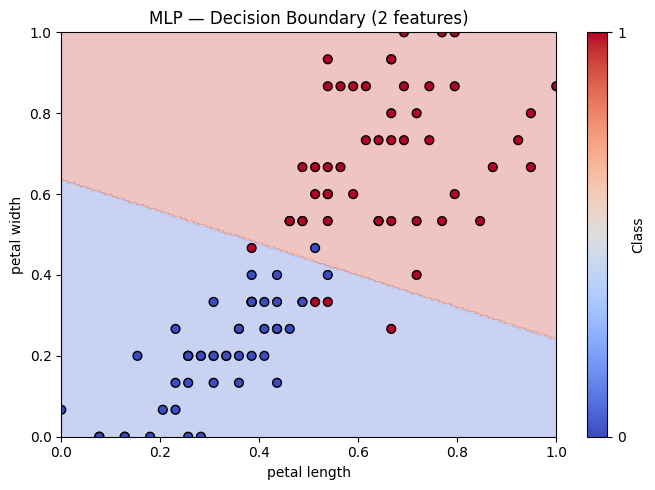

In [9]:
# --- Decision boundary (only for 2 features) ---
if N_FEATURES == 2:
    h = 0.005
    xx, yy = np.meshgrid(np.arange(0, 1 + h, h), np.arange(0, 1 + h, h))
    Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_full,
                          cmap="coolwarm", edgecolors="k", s=40)
    plt.colorbar(scatter, ticks=[0, 1], label="Class")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("MLP — Decision Boundary (2 features)")
    plt.tight_layout()
    plt.savefig("mlp_decision_boundary.png", dpi=150)
    plt.show()
else:
    print("Decision boundary plot skipped (only available for N_FEATURES=2).")

## Save Results

In [10]:
results = {
    # --- Experiment metadata ---
    "model"          : "MLP",
    "n_features"     : N_FEATURES,
    "feature_names"  : feature_names,
    "n_train"        : int(len(X_train)),
    "n_test"         : int(len(X_test)),
    "random_seed"    : RANDOM_SEED,
    # --- Architecture ---
    "hidden_layers"  : list(HIDDEN_LAYERS),
    "activation"     : "relu",
    "optimizer"      : "adam",
    "n_parameters"   : int(n_params),
    # --- Timing ---
    "train_time_s"   : float(train_time),
    "n_iter"         : int(mlp.n_iter_),
    # --- Accuracy ---
    "accuracy_test"  : float(acc_test),
    "accuracy_train" : float(acc_train),
    "cv_mean"        : float(cv_scores.mean()),
    "cv_std"         : float(cv_scores.std()),
    "cv_scores"      : cv_scores.tolist(),
    # --- Loss history ---
    "loss_curve"     : mlp.loss_curve_,
    # --- Predictions ---
    "y_test"         : y_test.tolist(),
    "y_pred_test"    : y_pred_test.tolist(),
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
print(json.dumps({k: v for k, v in results.items()
                  if k not in ("cv_scores", "loss_curve", "y_test", "y_pred_test")}, indent=2))

Results saved to mlp_results.json
{
  "model": "MLP",
  "n_features": 2,
  "feature_names": [
    "petal length",
    "petal width"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "hidden_layers": [
    4,
    4
  ],
  "activation": "relu",
  "optimizer": "adam",
  "n_parameters": 37,
  "train_time_s": 0.17838675400003012,
  "n_iter": 500,
  "accuracy_test": 0.8,
  "accuracy_train": 0.975,
  "cv_mean": 0.95,
  "cv_std": 0.04472135954999579
}
